## 트랜스포머(Transformer)
- 기존 seq2seq의 인코더-디코더 구조를 따르면서 RNN을 사용하지 않고 어텐션만으로 구현한 모델

#### 기존 seq2seq모델의 한계
- Context Vector로 시퀀스를 압축하는데 이 때 정보 소실

#### 트랜스포머
- 기존 seq2seq처럼 인코더-디코더 구조이지만 seq2seq처럼 인코더 디코더가 각각 하나의 RNN이 t개의 시점을 가지는 구조가 아닌 인코더 디코더가 N개로 구성되는 구조
- 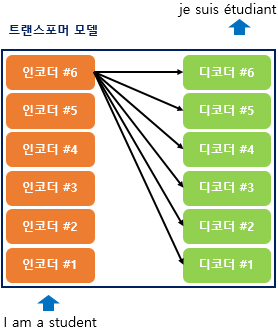

- 트랜스포머의 인코더 디코더 입력으로 임베딩 벡터들을 받는것이 아닌 임베딩 벡터에서 조정된 입력을 받음

#### 포지셔널 인코딩
- 트랜스포머는 기존 RNN처럼 입력을 순차적으로 받지 않음
- 트랜스포머는 임베딩 벡터에 각 위치 정보를 더함 -> 포지셔널 인코딩
- 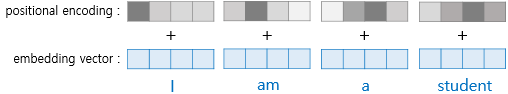

- 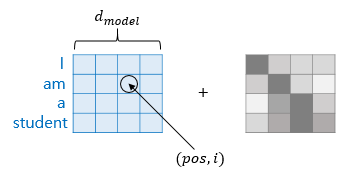

- $PE_{(pos, 2i)} = sin(pos/10000^{2i/d_{model}})$
- $PE_{(pos, 2i+1)} = cos(pos/10000^{2i/d_{model}})$
- 포지셔널 인코딩의 덧셈은 임베딩 벡터가 모여 만들어진 문장 행렬과 포지셔널 인코딩 행렬의 덧셈 연산임
- $d_{model}$은 트랜스포머의 모든 층의 출력 차원을 의미하는 하이퍼파라미터

#### 어텐션(Attention)
- 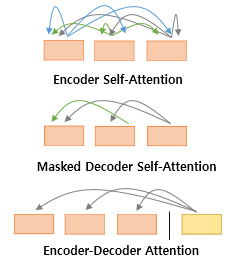

- 첫번째 self-attention은 본질적으로 Query, Key, Value가 동일한 경우를 말함
- 세번째 Encoder-Decoder Attention은 Query는 디코더의 벡터인 반면 Key와 Value가 인코더의 벡터임

- 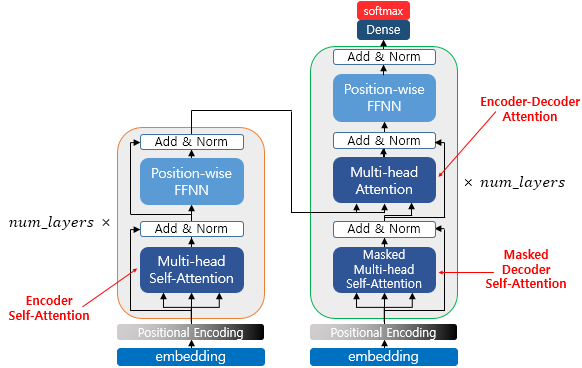

- Multi-head는 병렬적으로 수행한다는 뜻

#### 인코더(Encoder)
- 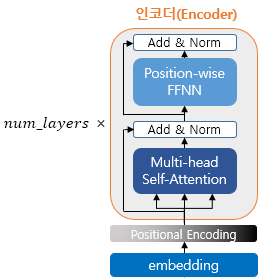

- num_layers개수의 인코더 층(논문에서는 6개)
- 하나의 인코더 층은 2개의 서브 층으로 나뉨(self-attention + feed-forward)

#### 인코더의 셀프 어텐션

- 셀프 어텐션의 의미와 이점
```
# seq2seq attention
Q = Query : t 시점의 디코더 셀에서의 은닉상태
K = Keys : 모든 시점의 인코더 셀의 은닉 상태들
V = Values : 모든 시점의 인코더 셀의 은닉 상태들
```
```
# self-attention
Q : 입력 문장의 모든 단어 벡터들
K : 입력 문장의 모든 단어 벡터들
V : 입력 문장의 모든 단어 벡터들
```
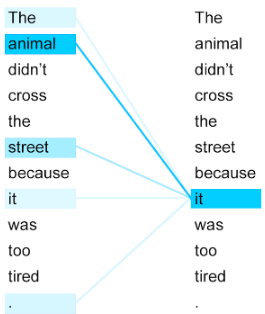

- Q, K, V 벡터 얻기
    - 앞서 self-attention은 입력 문장의 모든 단어 벡터들을 초기 입력으로 받는다 했지만 $d_{model}$ 차원의 단어 벡터들로 수행하지 않음
    - $d_{model}$을 트랜스포머의 하이퍼 파라미터인 num_heads로 나눈 값을 각 Q벡터, K벡터, V벡터의 차원으로 결정(논문에서는 8) -> multi-head로 나누는 과정
    - 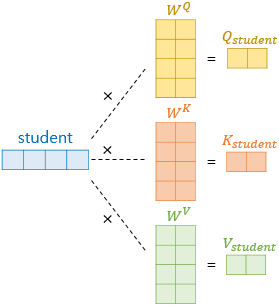

    - 각 가중치 $W^Q, W^K, W^V$는 $d_{model} \times (d_{model}/num\_heads)$의 크기를 갖는다.

- 스케일드 닷-프로덕트 어텐션(Scaled dot-product Attention)
    - 기존 어텐션 메커니즘처럼 Q벡터는 모든 K벡터에 대한 어텐션 스코어를 구하고, 어텐션 분포를 구한 후 모든 V벡터를 가중합하여 어텐션 값을 구한다. 모든 Q벡터에 대해서 반복.
    - 기존 닷-프로덕트 어텐션에서는 $score(q, k) = q \cdot k$ 인 반면,
    스케일드 닷-프로덕트 어텐션에서는 $score(q, k) = q \cdot k /\sqrt{n}$을 사용한다.

    - 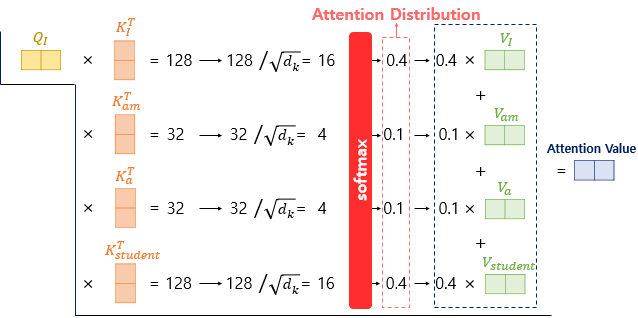

    - 128, 32는 임의의 숫자
    - $d_k$는 $d_{model}/num\_heads$
    - 위 그림은 I에 대한 어텐션값을 구한 것
    - 나머지 am, a, student 또한 동일하게 수행

- 행렬 연산으로 일괄 처리하기
    - 위에서 수행한 닷-프로덕트 어텐션은 각 단어를 일일히 수행했지만 실제 트랜스포머에서는 행렬 연산으로 일괄 계산이 가능
    - 여기서 구해진 Q행렬과 K행렬의 곱은 Q행렬에 K행렬을 전치해서 곱해준다.
    - 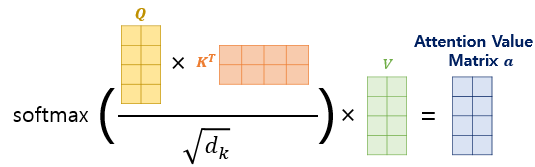

    - $Attention(Q, K, V) = softmax(\displaystyle\frac{QK^T}{\sqrt{d_k}})V$

    - 정리
        - 문장의 길이: seq_len
        - 문장 행렬의 크기: (seq_len, $d_model$)
        - Q행렬과 K행렬의 차원: $d_k$
        - V행렬의 차원: $d_v$
        - $d_k = d_v = d_{model}/num\_heads$
        - Q행렬과 K행렬의 크기: (seq_len, $d_k$)
        - V행렬의 크기: (seq_len, $d_v$)
        - $W^Q$와 $W^K$의 크기: ($d_{model}$, $d_k$)
        - $W^V$의 크기: ($d_{model}$, $d_v$)

- 멀티 헤드 어텐션(Multi-head Attention)
    - 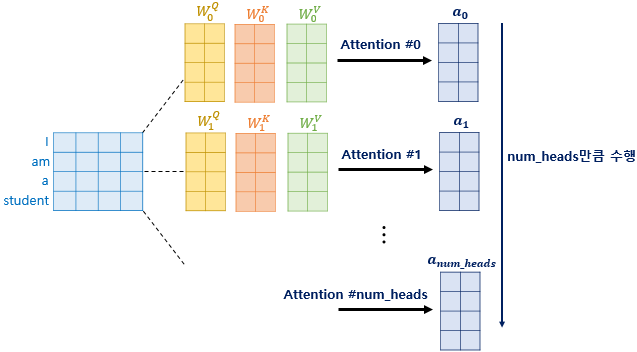

    - num_heads개의 병렬 어텐션을 수행
    - 가중치 행렬 $W^Q, W^K, W^V$의 값은 8개의 어텐션 헤드마다 전부 다름
    - 병렬 처리의 의미: 어텐션을 병렬로 수행하여 다른 시각으로 정보들을 수집하겠다는 의미
    - 병렬 어텐션을 모두 수행한 후 모든 어텐션 헤드들을 연결(concatenate)한다.
    - 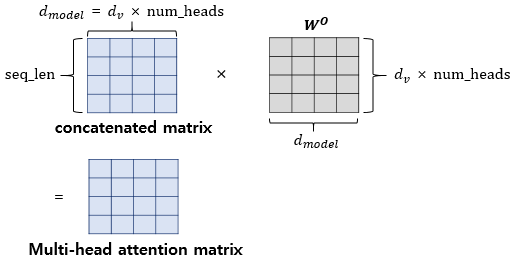

    - 모두 연결된 어텐션 헤드에 $W^o$가중치 행렬을 곱하고 최종 Multi-head Attention의 최종 결과이다.
    - 이 Multi-head Attention의 결과는 입력의 크기와 같은 (seq_len, $d_{model}$)이다.

- 패딩 마스크(Padding Mask)
    - 입력 문장에 \<PAD>토큰이 있을 경우 어텐션에서 제외하기 위한 연산입니다.
    - \<PAD>의 경우 의미없는 토큰이기 때문에 마스킹 작업을 수행한다.
    - 마스킹이란, 어텐션 계산을 제외하기 위한 작업이다.
    - 어텐션 스코어 행렬의 행은 Q, 열은 K이다. Key에 \<PAD>가 포함된 경우 해당 열 전체를 마스킹한다.
    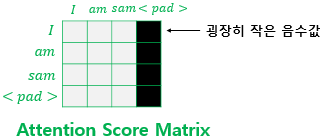

    - 굉장히 작은 음수값이란 -무한대에 가까운 수를 의미.
    - 현재 어텐션 스코어는 아직 소프트맥스 함수를 지나기 전이다.
    - -무한대에 가까운 수는 소프트맥스 함수를 지나게 되면 0이 된다.
    - 아래 그림은 소프트맥스 함수르 지난 어텐션 스코어이다.
    - 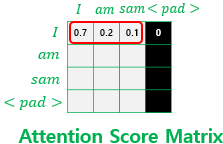

- 포지션-와이드 피드 포워드 신경망(Position-wise FFNN)
    - 포지션-와이드 피드 포워드 신경망은 인코더, 디코더층 모두 존재한다.
    - FFNN은 Fully-connected neural network로 완전연결 신경망이다.
    - $FFNN(x) = MAX(0, xW_1 + b_1)W_2 + b_2$
    - 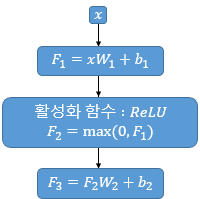

    - x는 Multi-head Attention의 결과인 (seq_len, $d_{model}$)크기의 행렬을 의미
    - $W_1$은 ($d_{model}, $d_{ff}$)의 크기를 가지고, 행렬 $W_2$는 ($d_{ff}, d_{model}$)의 크기를 가진다.
    - $d_{ff}$는 하이퍼 파라미터로 논문에서는 2048의 크기이다.
    - 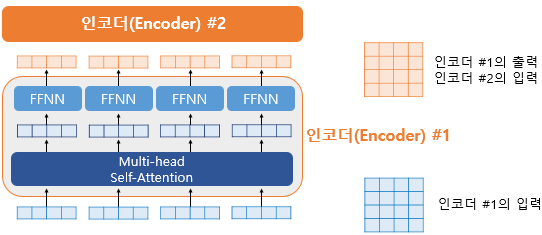

- 잔차 연결(Residual connection)과 층 정규화(Layer Normalization)
    - 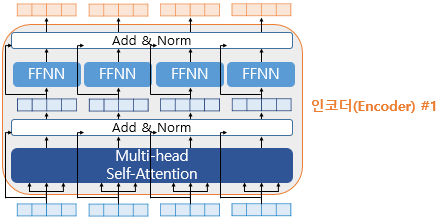
    - Add & Norm 부분이 잔차연결과 층 정규화를 의미한다.
    - 잔차 연결
        - 잔차 연결을 식으로 표현하면 $H(x) = x + F(x)$
        - 잔차 연결은 서브층의 입력과 출력을 더하는 것을 의미
        - 트랜스포머에서 입력과 출력값은 크기가 동일하기 때문에 합연산이 가능하다.
        - Multi-head Attention에서 잔차 연결 식은 $H(x) = x + Multi\_head Attention(x)$
    - 층 정규화
        - $LN = LayerNorm(x + Sublayer(x))$
        - 층 정규화는 텐서의 마지막 차원에 대해 평균과 분산을 구하고, 이를 가지고 어떤 수식을 통해 값을 정규화하여 학습을 돕는다.
        - 텐서의 마지막 차원은 $d_{model}$차원을 의미한다.
        - 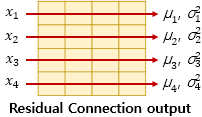
        - 화살표 방향으로 평균 $\mu$와 분산 $\sigma^2$을 구한다.
        - $x_i$는 벡터 평균과 분산은 스칼라이다.
        - 벡터 $x_i$의 차원을 k라고 했을 때 $x_{i,k}$의 수식은 다음과 같이 정규화 할 수 있다
        - $\hat{x}_{i,k} = \displaystyle\frac{x_{i,k}-\mu_i}{\sqrt{{\sigma_i}^2 + \epsilon}}$
        - 엡실론은 분모가 0이 되는 것을 방지한다.
        - 이후 $\gamma$와 $\beta$ 벡터를 준비한다.
        - 최종 수식
        - $ln_i = \gamma\hat{x}_i + \beta = LayerNorm(x_i)$
    
- 인코더에서 디코더로
    - 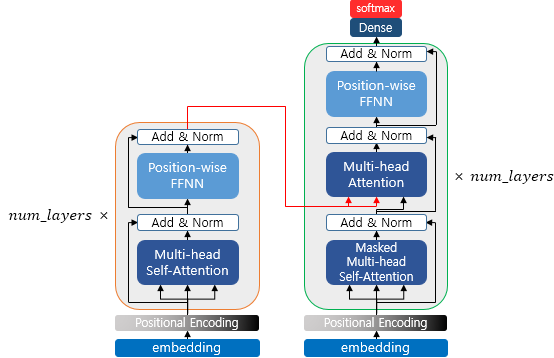

    - 인코더 층 num_layers만큼 층 연산을 마치고 출력을 디코더층으로 전달한다.
    - 디코더층에서도 num_layers만큼 층 연산을 수행한다.

- 디코더의 첫번째 서브층: 셀프 어텐션과 룩-어헤드 마스크
    - 디코더층도 인코더와 동일하게 임베딩 층과 포지셔널 인코딩을 거친 후의 문장 행렬이 입력된다.
    - seq2seq와 같이 트랜스포머도 교사강요(Teacher Forcing) 학습법이 사용된다.
    - 트랜스포머는 seq2seq처럼 순차적 연산이 아닌 병렬 연산을 진행하기 때문에 현재 시점보다 앞선 미래에 있는 단어들을 참고할 수 있음
    - 때문에 look-ahead mask를 도입한다.
    - 이는 '미리보기에 대한 마스크'라는 뜻이다.
    - 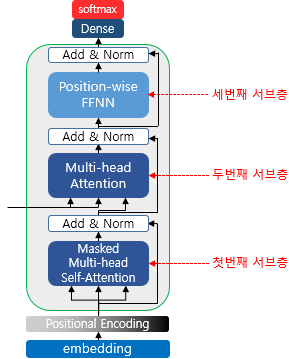

    - look-ahead mask는 디코더의 첫번째 서브층에서 이루어진다.
    - 디코더의 첫번째 Masked Multi-head Self-Attention은 인코더층과 동일하게 진행되지만 다른 점은 어텐션 스코어 행렬에서 마스킹을 적용한다.
    - 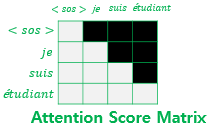

    - 자기 자신보다 미래에 있는 단어들은 참고하지 못하게 마스킹 작업을 수행한다.

- 디코더의 두번째 서브층: 인코더-디코더 어텐션
    - 인코더-디코더 어텐션또한 멀티-헤드 어텐션이다.
    - 다만 셀프 어텐션이 아닌 Query는 디코더 행렬에서 Key와 Value는 인코더 행렬이다.